# Inequações Exponenciais e Logarítmicas

**Módulo:** 02 – Logaritmos

**Pré-requisitos:** [`0205a_equacoes_exponenciais_e_logaritmicas.ipynb`](0205a_equacoes_exponenciais_e_logaritmicas.ipynb) (técnicas gerais com logaritmo para equações), [`0204a_funcao_logaritmica.ipynb`](0204a_funcao_logaritmica.ipynb) (comportamento crescente/decrescente da função logarítmica) e [`0202a_funcao_exponencial.ipynb`](0202a_funcao_exponencial.ipynb) (regra simples de inversão de sinal em inequações exponenciais de base igual)

**Objetivos de aprendizagem:**
- Resolver inequações exponenciais gerais usando logaritmo, aplicando corretamente a regra de inversão de sinal quando 0 < a < 1.
- Resolver inequações exponenciais por substituição de variável, respeitando a restrição aˣ > 0.
- Resolver inequações logarítmicas diretas e com logaritmo dos dois lados, sempre intersectando com o domínio.
- Visualizar, com Python, a região-solução de uma inequação exponencial ou logarítmica.

**Tempo estimado:** 80 a 100 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/02_logaritmos/0206a_inequacoes_exponenciais_e_logaritmicas.ipynb)

## Por quanto tempo o remédio ainda faz efeito?

Um remédio tem sua concentração no sangue modelada por

$$C(t) = C_0 \cdot (0{,}5)^{t/6}$$

em que t é o tempo em horas e a meia-vida do remédio é de 6 horas — a cada 6 horas, a concentração cai pela metade. Só que o remédio só faz efeito enquanto sua concentração fica **acima** de um nível terapêutico mínimo.

**A partir de quantas horas o paciente precisa tomar uma nova dose, para a concentração não cair abaixo desse nível?**

Repare que essa pergunta é diferente das que resolvemos no notebook de equações: ali, buscávamos o instante exato em que C(t) era igual a um valor. Aqui, queremos saber **para quais valores de t** a concentração continua acima do mínimo — a resposta não é um número, é um **intervalo de tempo válido**.

Ao final deste notebook, você vai resolver esse problema com precisão, inclusive conferindo a resposta com um gráfico.

📖 **Leitura complementar:** [Decaimento exponencial](https://pt.wikipedia.org/wiki/Decaimento_exponencial)

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp
import ipywidgets as widgets
from scipy.optimize import brentq

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    '''Aplica o estilo Nord padrão a um eixo do matplotlib.'''
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)

## 1. Inequações Exponenciais Gerais (Usando Logaritmo)

📌 **Definição formal:** para resolver uma inequação exponencial que não se reduz a uma base comum, isolamos a potência de um lado e aplicamos logaritmo dos dois lados — exatamente como fizemos com as equações em `0205a_equacoes_exponenciais_e_logaritmicas`. A diferença é que, ao isolar x, se for preciso **dividir por log(a)** e log(a) for **negativo** (o que acontece quando 0 < a < 1), **o sentido da desigualdade se inverte**:

$$a^x > b \implies x \cdot \log(a) > \log(b) \implies \begin{cases} x > \dfrac{\log(b)}{\log(a)}, & \text{se } a>1 \ (\log a > 0,\ \text{mantém}) \\[6pt] x < \dfrac{\log(b)}{\log(a)}, & \text{se } 0<a<1 \ (\log a < 0,\ \text{inverte}) \end{cases}$$

⚠️ **Erro comum:** aplicar log dos dois lados e isolar x sem checar o sinal de log(a). É a mesma regra vista de forma simples em `0202a_funcao_exponencial` (quando as bases já eram iguais), agora generalizada para qualquer base.

In [2]:
# a) 3^x > 50   (base a=3 > 1  ->  mantém o sentido)
x_fronteira_a = math.log(50) / math.log(3)
print("a) 3^x > 50")
print(f"   x*log(3) > log(50)  ->  x > log(50)/log(3) = {x_fronteira_a:.4f}   (log(3) > 0, mantém)")

# b) (0,5)^x < 10   (base a=0,5, com 0<a<1  ->  inverte o sentido)
x_fronteira_b = math.log(10) / math.log(0.5)
print("\nb) (0,5)^x < 10")
print(f"   x*log(0,5) < log(10)  ->  x > log(10)/log(0,5) = {x_fronteira_b:.4f}   (log(0,5) < 0, INVERTE)")

# Representação numérica: tabela de valores em torno da fronteira do item b)
tabela_b = pd.DataFrame({"x": np.round(np.linspace(x_fronteira_b - 1, x_fronteira_b + 1, 5), 2)})
tabela_b["(0,5)^x"] = (0.5 ** tabela_b["x"]).round(4)
tabela_b["satisfaz (0,5)^x < 10 ?"] = tabela_b["(0,5)^x"] < 10
tabela_b

a) 3^x > 50
   x*log(3) > log(50)  ->  x > log(50)/log(3) = 3.5609   (log(3) > 0, mantém)

b) (0,5)^x < 10
   x*log(0,5) < log(10)  ->  x > log(10)/log(0,5) = -3.3219   (log(0,5) < 0, INVERTE)


,x,"(0,5)^x","satisfaz (0,5)^x < 10 ?"
0,-4.32,19.9733,False
1,-3.82,14.1232,False
2,-3.32,9.9866,True
3,-2.82,7.0616,True
4,-2.32,4.9933,True


🕹️ **Widget interativo:** escolha a base a e o tipo de comparação (aˣ > c ou aˣ < c). O gráfico sombreia a região-solução e mostra a fronteira x — repare como a sombra "vira de lado" quando a cruza o valor 1.

In [3]:
def explorar_inequacao_exponencial(a: float, c: float, tipo: str) -> None:
    if abs(a - 1) < 1e-6:
        print("a = 1 não define uma exponencial de verdade (1^x = 1 sempre) -- escolha outro valor de a.")
        return

    log_a = math.log(a)
    inverte = log_a < 0
    xs = np.linspace(-6, 6, 600)
    ys = a**xs

    fig, ax = plt.subplots(figsize=(7, 5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)

    cor_curva = COR_PONTO if a > 1 else COR_ALERTA
    ax.plot(xs, ys, color=cor_curva, linewidth=2.2, label=f"{a:g}ˣ")
    ax.axhline(c, color=COR_AVISO, linewidth=1.6, linestyle="--", label=f"y = {c:g}")

    if c <= 0:
        print(f"como {a:g}^x é sempre positivo e c = {c:g} <= 0:")
        if tipo == "a^x > c":
            print("  a inequação vale para TODO x real.")
        else:
            print("  a inequação NUNCA é satisfeita.")
    else:
        x_fronteira = math.log(c) / log_a
        satisfaz = (ys > c) if tipo == "a^x > c" else (ys < c)
        ax.fill_between(xs, 0, ys, where=satisfaz, color=COR_DESTAQUE, alpha=0.25)
        ax.axvline(x_fronteira, color=NORD_TEXTO, linewidth=1, linestyle=":")
        ax.annotate(f"x = {x_fronteira:.2f}", (x_fronteira, c), textcoords="offset points",
                    xytext=(8, 10), color=NORD_TEXTO, fontsize=9)
        sentido = "<" if (tipo == "a^x > c") == inverte else ">"
        print(f"{a:g}^x {'>' if tipo == 'a^x > c' else '<'} {c:g}  ->  x {sentido} {x_fronteira:.4f}")
        print(f"log({a:g}) = {log_a:.4f}  ({'negativo -> INVERTE' if inverte else 'positivo -> mantém'})")

    limite_sup = min(max(ys.max(), c) * 1.2, 60)
    ax.set_ylim(-1, limite_sup)
    ax.set_xlabel("x", color=NORD_TEXTO_SEC)
    ax.set_ylabel("y", color=NORD_TEXTO_SEC)
    ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA, fontsize=10)
    plt.show()


widgets.interact(
    explorar_inequacao_exponencial,
    a=widgets.FloatSlider(value=2.0, min=0.1, max=4.0, step=0.1, description="a:"),
    c=widgets.FloatSlider(value=10.0, min=1.0, max=50.0, step=1.0, description="c:"),
    tipo=widgets.Dropdown(options=["a^x > c", "a^x < c"], value="a^x > c", description="tipo:"),
)

interactive(children=(FloatSlider(value=2.0, description='a:', max=4.0, min=0.1), FloatSlider(value=10.0, desc…

<function __main__.explorar_inequacao_exponencial(a: float, c: float, tipo: str) -> None>

**Pergunta de checagem:** por que dividir os dois lados de uma desigualdade por um número negativo inverte o sinal — e como isso se conecta com log(a) ser negativo quando 0 < a < 1?

🎯 **Aplicação prática:** primeira parte da resolução do problema do gancho — descobrir por quanto tempo a concentração do remédio se mantém acima do nível mínimo.

In [4]:
# Aplicação: primeira parte do problema do gancho
C0 = 100          # concentração inicial (mg/L)
nivel_minimo = 25  # nível terapêutico mínimo (mg/L)
meia_vida = 6      # horas

# C0*(0,5)^(t/meia_vida) >= nivel_minimo  ->  (0,5)^(t/meia_vida) >= nivel_minimo/C0
razao = nivel_minimo / C0
print(f"C0*(0,5)^(t/{meia_vida}) >= {nivel_minimo}  ->  (0,5)^(t/{meia_vida}) >= {razao:g}")

# aplicando log: (t/meia_vida)*log(0,5) >= log(razao)
# log(0,5) < 0  ->  ao dividir por ele, o sentido INVERTE
t_max = meia_vida * math.log(razao) / math.log(0.5)
print(f"(t/{meia_vida})*log(0,5) >= log({razao:g})  ->  t <= {meia_vida}*log({razao:g})/log(0,5) = {t_max:.1f} horas")
print(f"\nresposta parcial: a concentração fica acima do nível mínimo para 0 <= t <= {t_max:.0f} horas")
print("(vamos confirmar isso com um gráfico no final do notebook)")

C0*(0,5)^(t/6) >= 25  ->  (0,5)^(t/6) >= 0.25
(t/6)*log(0,5) >= log(0.25)  ->  t <= 6*log(0.25)/log(0,5) = 12.0 horas

resposta parcial: a concentração fica acima do nível mínimo para 0 <= t <= 12 horas
(vamos confirmar isso com um gráfico no final do notebook)


## 2. Inequações Exponenciais por Substituição de Variável

📌 **Definição formal:** quando a inequação envolve potências de aˣ elevadas a outros expoentes, fazemos a substituição y = aˣ, transformando a inequação exponencial numa inequação polinomial (em geral, quadrática) em y. Resolvemos para y e, **antes de voltar para x**, sempre intersectamos com y > 0 — pois aˣ nunca é zero nem negativo. Essa restrição é ainda mais importante aqui do que era nas equações: lá, descartávamos raízes isoladas; aqui, podemos precisar cortar um intervalo inteiro.

In [5]:
# Resolvendo 4^x - 5*2^x + 4 < 0 por substituição: y = 2^x
# Repare que 4^x = (2^2)^x = (2^x)^2 = y^2
y = sp.symbols("y", real=True)
inequacao_em_y = sp.Lt(y**2 - 5 * y + 4, 0)
solucao_y = sp.solve_univariate_inequality(inequacao_em_y, y, relational=False)
print("4^x - 5*2^x + 4 < 0")
print("substituindo y = 2^x:", inequacao_em_y, " ->  y em", solucao_y)

solucao_y_valida = solucao_y.intersect(sp.Interval.open(0, sp.oo))
print("intersectando com y > 0 (pois 2^x nunca é <= 0):  y em", solucao_y_valida)

x_ini = sp.log(solucao_y_valida.start, 2) if solucao_y_valida.start > 0 else -sp.oo
x_fim = sp.log(solucao_y_valida.end, 2) if solucao_y_valida.end != sp.oo else sp.oo
print(f"\nvoltando para x (y = 2^x):  {float(x_ini):g} < x < {float(x_fim):g}")

4^x - 5*2^x + 4 < 0
substituindo y = 2^x: y**2 - 5*y + 4 < 0  ->  y em Interval.open(1, 4)
intersectando com y > 0 (pois 2^x nunca é <= 0):  y em Interval.open(1, 4)

voltando para x (y = 2^x):  0 < x < 2


🕹️ **Widget interativo:** ajuste a base a e os coeficientes p, q da inequação (aˣ)² + p·aˣ + q ◇ 0. O widget resolve a inequação polinomial em y, intersecta com y > 0 e converte o(s) intervalo(s) restante(s) de volta para x.

In [6]:
def substituicao_inequacao(a: float, p: float, q: float, tipo: str) -> None:
    y = sp.symbols("y", real=True)
    expr = y**2 + p * y + q
    relacao = sp.Lt(expr, 0) if tipo == "< 0" else sp.Gt(expr, 0)
    solucao_y = sp.solve_univariate_inequality(relacao, y, relational=False)
    solucao_y_valida = solucao_y.intersect(sp.Interval.open(0, sp.oo))

    print(f"({a:g}^x)^2 + ({p:g})*{a:g}^x + ({q:g}) {tipo}")
    print(f"substituindo y = {a:g}^x:  y^2 + ({p:g})y + ({q:g}) {tipo}  ->  y em {solucao_y}")
    print(f"intersectando com y > 0 (pois {a:g}^x nunca é <= 0):  y em {solucao_y_valida}")

    intervalos = solucao_y_valida.args if isinstance(solucao_y_valida, sp.Union) else [solucao_y_valida]
    log_a = math.log(a)
    print("\nvoltando para x (y = a^x):")
    encontrou = False
    for intervalo in intervalos:
        if intervalo is sp.EmptySet:
            continue
        encontrou = True
        ini = float(intervalo.start)
        fim = float(intervalo.end)
        x_ini_txt = "-∞" if ini <= 0 else f"{math.log(ini, a):.4f}"
        x_fim_txt = "∞" if intervalo.end == sp.oo else f"{math.log(fim, a):.4f}"
        if log_a > 0:
            print(f"  {x_ini_txt} < x < {x_fim_txt}")
        else:
            print(f"  {x_fim_txt} < x < {x_ini_txt}   (base 0<a<1: intervalo também se inverte)")
    if not encontrou:
        print("  nenhuma solução real.")


widgets.interact(
    substituicao_inequacao,
    a=widgets.FloatSlider(value=2.0, min=1.1, max=5.0, step=0.1, description="a:"),
    p=widgets.FloatSlider(value=-5.0, min=-10.0, max=10.0, step=0.5, description="p:"),
    q=widgets.FloatSlider(value=4.0, min=-10.0, max=10.0, step=0.5, description="q:"),
    tipo=widgets.Dropdown(options=["< 0", "> 0"], value="< 0", description="tipo:"),
)

interactive(children=(FloatSlider(value=2.0, description='a:', max=5.0, min=1.1), FloatSlider(value=-5.0, desc…

<function __main__.substituicao_inequacao(a: float, p: float, q: float, tipo: str) -> None>

**Pergunta de checagem:** por que a restrição y > 0 é ainda mais importante aqui do que era ao resolver equações por substituição?

🎯 **Aplicação prática:** esse tipo de inequação aparece ao determinar o intervalo de tempo em que uma grandeza formada por dois termos exponenciais (como a carga de um capacitor num circuito RC) permanece dentro de uma faixa segura.

## 3. Inequações Exponenciais com Bases Diferentes

📌 **Definição formal:** quando as bases não são relacionáveis diretamente (como 2 e 3), aplicamos log dos dois lados e isolamos x algebricamente, agrupando os termos que o contêm. Como antes, o sinal do coeficiente que multiplica x, depois de agrupado, decide se o sentido da desigualdade se mantém ou se inverte ao dividir.

In [7]:
# Resolvendo 2^x < 3^(x-1)
log2, log3 = math.log(2), math.log(3)
# log(2^x) < log(3^(x-1))  ->  x*log2 < (x-1)*log3  ->  x*log2 - x*log3 < -log3
# x*(log2 - log3) < -log3
coeficiente = log2 - log3
print("2^x < 3^(x-1)")
print("x*log(2) < (x-1)*log(3)  ->  x*(log(2) - log(3)) < -log(3)")
print(f"coeficiente de x: log(2)-log(3) = {coeficiente:.4f}  (negativo -> INVERTE ao dividir)")

x_fronteira = -log3 / coeficiente
print(f"x > -log(3)/(log(2)-log(3)) = {x_fronteira:.4f}")
print(f"\nconferindo x=3: 2^3={2**3}  3^(3-1)={3**(3-1)}  ({2**3} < {3**(3-1)}? {2**3 < 3**(3 - 1)})")
print(f"conferindo x=2: 2^2={2**2}  3^(2-1)={3**(2 - 1)}  ({2**2} < {3**(2 - 1)}? {2**2 < 3**(2 - 1)})")

# Aplicação: dois investimentos com taxas diferentes -- a partir de quando um supera o outro?
capital_a, taxa_a = 1000, 0.10
capital_b, taxa_b = 1500, 0.06
# capital_a*(1+taxa_a)^t > capital_b*(1+taxa_b)^t
t_cruzamento = (math.log(capital_b) - math.log(capital_a)) / (math.log(1 + taxa_a) - math.log(1 + taxa_b))
print(f"\ninvestimento A (R${capital_a}, {taxa_a:.0%} a.a.) supera investimento B (R${capital_b}, {taxa_b:.0%} a.a.)")
print(f"quando t > {t_cruzamento:.2f} anos")

2^x < 3^(x-1)
x*log(2) < (x-1)*log(3)  ->  x*(log(2) - log(3)) < -log(3)
coeficiente de x: log(2)-log(3) = -0.4055  (negativo -> INVERTE ao dividir)
x > -log(3)/(log(2)-log(3)) = 2.7095

conferindo x=3: 2^3=8  3^(3-1)=9  (8 < 9? True)
conferindo x=2: 2^2=4  3^(2-1)=3  (4 < 3? False)

investimento A (R$1000, 10% a.a.) supera investimento B (R$1500, 6% a.a.)
quando t > 10.95 anos


**Pergunta de checagem:** como decidir, nesse tipo de problema, se o sinal da desigualdade se mantém ou se inverte ao isolar x?

🎯 **Aplicação prática:** essa técnica responde "a partir de quando um investimento com taxa maior ultrapassa outro que começou com capital maior, mas rende menos?" (veja o exemplo acima).

## 4. Inequações Logarítmicas Diretas

📌 **Definição formal:** para uma inequação com log_a(f(x)) comparado a uma constante c, "desfazemos" o logaritmo exponenciando os dois lados na base a — com a mesma regra de inversão de sempre: se a > 1, o sentido se mantém; se 0 < a < 1, o sentido se inverte:

$$\log_a(f(x)) > c \iff \begin{cases} f(x) > a^c, & a > 1 \\ 0 < f(x) < a^c, & 0 < a < 1 \end{cases}$$

⚠️ **Erro comum:** esquecer que f(x) > 0 é sempre parte da resposta, mesmo quando a exponenciação já "resolve" a desigualdade — mais sobre isso no bloco 6.

In [8]:
# a) log_2(x) > 3   (base a=2 > 1  ->  mantém)
x_a = 2**3
print(f"a) log_2(x) > 3         ->  x > 2^3 = {x_a}")

# b) log_(0,5)(x) > 3   (base 0<a<1  ->  inverte, e ainda precisa de x>0)
x_b = 0.5**3
print(f"b) log_0,5(x) > 3       ->  0 < x < 0,5^3 = {x_b:g}   (INVERTE, pois 0<0,5<1)")

# Aplicação: escala de decibéis -- a partir de que intensidade sonora um som ultrapassa um valor em dB?
# beta(dB) = 10*log10(I/I0), com I0 = 1e-12 W/m^2 (limiar de audição)
I0 = 1e-12
limite_db = 70
I_minima = I0 * 10 ** (limite_db / 10)
print(f"\nbeta(dB) = 10*log10(I/{I0:g}) > {limite_db}   (base 10 > 1, mantém)")
print(f"log10(I/{I0:g}) > {limite_db / 10:g}  ->  I > {I0:g}*10^{limite_db / 10:g} = {I_minima:g} W/m²"
      f"  para ultrapassar {limite_db} dB")

a) log_2(x) > 3         ->  x > 2^3 = 8
b) log_0,5(x) > 3       ->  0 < x < 0,5^3 = 0.125   (INVERTE, pois 0<0,5<1)

beta(dB) = 10*log10(I/1e-12) > 70   (base 10 > 1, mantém)
log10(I/1e-12) > 7  ->  I > 1e-12*10^7 = 1e-05 W/m²  para ultrapassar 70 dB


🕹️ **Widget interativo:** ajuste a base a (sempre maior que 1) e a constante c. O painel da esquerda mostra log_a(x) > c e o da direita, com a base recíproca 1/a (sempre entre 0 e 1), mostra log_(1/a)(x) > c — lado a lado, para comparar como a mesma constante c gera regiões-solução opostas.

In [9]:
def comparar_logs_lado_a_lado(a: float, c: float) -> None:
    a_maior, a_menor = a, 1 / a
    xs = np.linspace(0.01, 20, 600)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    for ax, base, cor in [(ax1, a_maior, COR_PONTO), (ax2, a_menor, COR_ALERTA)]:
        estilizar_eixo(ax)
        ys = np.log(xs) / np.log(base)
        ax.plot(xs, ys, color=cor, linewidth=2.2)
        ax.axhline(c, color=COR_AVISO, linewidth=1.4, linestyle="--")
        fronteira = base**c
        satisfaz = ys > c
        ax.fill_between(xs, ys.min(), ys, where=satisfaz, color=COR_DESTAQUE, alpha=0.25)
        ax.axvline(fronteira, color=NORD_TEXTO, linewidth=1, linestyle=":")
        ax.set_title(f"log_{base:.2f}(x) > {c:g}  ->  x{'>' if base > 1 else '<'}{fronteira:.2f}",
                     color=NORD_TEXTO, fontsize=10)
        ax.set_xlabel("x", color=NORD_TEXTO_SEC)
        ax.set_ylabel("y", color=NORD_TEXTO_SEC)
    plt.show()


widgets.interact(
    comparar_logs_lado_a_lado,
    a=widgets.FloatSlider(value=2.0, min=1.1, max=5.0, step=0.1, description="a:"),
    c=widgets.FloatSlider(value=3.0, min=-3.0, max=5.0, step=0.5, description="c:"),
)

interactive(children=(FloatSlider(value=2.0, description='a:', max=5.0, min=1.1), FloatSlider(value=3.0, descr…

<function __main__.comparar_logs_lado_a_lado(a: float, c: float) -> None>

**Pergunta de checagem:** por que, ao "desfazer" um logaritmo de base entre 0 e 1, a desigualdade se inverte?

🎯 **Aplicação prática:** retomando os decibéis vistos em `0204a_funcao_logaritmica` — a partir de que intensidade sonora física um som ultrapassa um determinado nível em decibéis.

## 5. Inequações Logarítmicas com Logaritmo dos Dois Lados

📌 **Definição formal:** quando os dois lados da inequação já são logaritmos de mesma base, comparamos diretamente os logaritmandos — mas atenção à base: se a > 1, a comparação entre f(x) e g(x) mantém o sentido; se 0 < a < 1, ela se inverte:

$$\log_a(f(x)) > \log_a(g(x)) \implies \begin{cases} f(x) > g(x), & a>1 \\ f(x) < g(x), & 0<a<1 \end{cases}$$

In [10]:
# a) log(x+1) < log(2x-3)   (base 10 > 1  ->  mantém)
print("a) log(x+1) < log(2x-3)   (base 10 > 1, mantém)")
print("   x+1 < 2x-3  ->  x > 4")
print("   domínio: x+1>0 (x>-1) e 2x-3>0 (x>1,5)  ->  x>4 já satisfaz os dois")

# b) log_(0,5)(3x-1) < log_(0,5)(x+5)   (base 0<a<1  ->  inverte)
print("\nb) log_0,5(3x-1) < log_0,5(x+5)   (base 0<0,5<1, INVERTE)")
print("   3x-1 > x+5  ->  x > 3")
print("   domínio: 3x-1>0 (x>1/3) e x+5>0 (x>-5)  ->  x>3 já satisfaz os dois")

a) log(x+1) < log(2x-3)   (base 10 > 1, mantém)
   x+1 < 2x-3  ->  x > 4
   domínio: x+1>0 (x>-1) e 2x-3>0 (x>1,5)  ->  x>4 já satisfaz os dois

b) log_0,5(3x-1) < log_0,5(x+5)   (base 0<0,5<1, INVERTE)
   3x-1 > x+5  ->  x > 3
   domínio: 3x-1>0 (x>1/3) e x+5>0 (x>-5)  ->  x>3 já satisfaz os dois


**Pergunta de checagem:** por que ainda precisamos ficar de olho na base, mesmo quando os dois lados da inequação já são logaritmos?

🎯 **Aplicação prática:** comparações científicas entre grandezas medidas na mesma escala logarítmica — por exemplo, a energia liberada por dois terremotos na escala Richter, em que a base (10) é sempre maior que 1 e a comparação mantém o sentido direto.

📖 **Leitura complementar:** [Escala de Richter](https://pt.wikipedia.org/wiki/Escala_de_Richter)

## 6. Interseção do Domínio com a Solução

⚠️ **Erro comum:** a solução final de qualquer inequação logarítmica deve ser a **interseção** entre a solução algébrica da desigualdade **e** as condições de existência (logaritmando > 0) de cada logaritmo presente na inequação original. Resolver só a álgebra e esquecer o domínio é um dos erros mais comuns em provas — e pode entregar uma resposta maior (e errada) do que a correta.

In [11]:
# log(x-2) + log(x+2) < log(5)
# usando a propriedade do produto: log(x-2)+log(x+2) = log((x-2)(x+2))
print("log(x-2) + log(x+2) < log(5)")
print("log((x-2)(x+2)) < log(5)  ->  (x-2)(x+2) < 5  ->  x^2 - 4 < 5  ->  x^2 < 9")
print("solução algébrica: -3 < x < 3")

print("\ndomínio: x-2>0  E  x+2>0  ->  x>2")
print("interseção entre (-3,3) e (2,+inf):  2 < x < 3")
print("\nrepare: a álgebra sozinha (-3<x<3) sugeriria valores como x=-1 ou x=0,")
print("mas nenhum deles satisfaz x>2 -- por isso são descartados.")

log(x-2) + log(x+2) < log(5)
log((x-2)(x+2)) < log(5)  ->  (x-2)(x+2) < 5  ->  x^2 - 4 < 5  ->  x^2 < 9
solução algébrica: -3 < x < 3

domínio: x-2>0  E  x+2>0  ->  x>2
interseção entre (-3,3) e (2,+inf):  2 < x < 3

repare: a álgebra sozinha (-3<x<3) sugeriria valores como x=-1 ou x=0,
mas nenhum deles satisfaz x>2 -- por isso são descartados.


🕹️ **Widget interativo:** ajuste a constante c em log(x-2) + log(x+2) < log(c). O gráfico mostra, numa reta numérica, a solução algébrica, o domínio (x>2) e a interseção final entre os dois.

In [12]:
def visualizar_intersecao(c: float) -> None:
    if c <= 0:
        print("c precisa ser > 0 para log(c) existir.")
        return

    limite = math.sqrt(c + 4)
    dominio_ini = 2
    inter_ini = max(-limite, dominio_ini)
    inter_fim = limite

    fig, ax = plt.subplots(figsize=(8, 3.2))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)

    ax.hlines(1, -limite, limite, color=COR_SECUNDARIA, linewidth=7)
    ax.hlines(2, dominio_ini, dominio_ini + max(limite, 4), color=COR_AVISO, linewidth=7)
    if inter_ini < inter_fim:
        ax.hlines(3, inter_ini, inter_fim, color=COR_DESTAQUE, linewidth=7)
        resultado = f"{inter_ini:.2f} < x < {inter_fim:.2f}"
    else:
        resultado = "interseção vazia -- nenhuma solução real"

    ax.set_yticks([1, 2, 3])
    ax.set_yticklabels(["algébrica", "domínio (x>2)", "final"], color=NORD_TEXTO_SEC)
    ax.set_ylim(0.3, 3.7)
    ax.set_xlim(-limite - 1, dominio_ini + max(limite, 4) + 1)
    ax.set_xlabel("x", color=NORD_TEXTO_SEC)
    ax.set_title(f"log(x-2)+log(x+2) < log({c:g})  ->  {resultado}", color=NORD_TEXTO, fontsize=10)
    plt.show()


widgets.interact(
    visualizar_intersecao,
    c=widgets.FloatSlider(value=5.0, min=0.1, max=20.0, step=0.1, description="c:"),
)

interactive(children=(FloatSlider(value=5.0, description='c:', max=20.0, min=0.1), Output()), _dom_classes=('w…

<function __main__.visualizar_intersecao(c: float) -> None>

**Pergunta de checagem:** por que a solução final de uma inequação logarítmica quase nunca é apenas "resolver a desigualdade"?

🎯 **Aplicação prática:** esse é um dos erros mais comuns em provas e vestibulares — esquecer de intersectar com o domínio, entregando uma resposta maior (e errada) do que a correta.

## 7. Visualização da Região-Solução com Python

📌 **Conexão:** gráficos ajudam a visualizar a região-solução de uma inequação exponencial ou logarítmica — sombreamos a área em que a desigualdade é satisfeita, cruzando o gráfico da função com uma reta (ou curva) de referência. É a mesma ideia usada nos widgets anteriores, agora aplicada ao problema do gancho.

🕹️ **Widget interativo:** ajuste a concentração inicial C0, a meia-vida e o nível terapêutico mínimo do remédio. O gráfico plota C(t), a linha do nível mínimo e sombreia em vermelho a região em que a concentração já é insuficiente.

In [13]:
def visualizar_remedio(C0: float, meia_vida: float, nivel_minimo: float) -> float | None:
    ts = np.linspace(0, 40, 600)
    concentracoes = C0 * 0.5 ** (ts / meia_vida)

    def diferenca(t):
        return C0 * 0.5 ** (t / meia_vida) - nivel_minimo

    t_limite = None
    if nivel_minimo < C0 and diferenca(ts[-1]) < 0:
        t_limite = brentq(diferenca, 0, ts[-1])

    fig, ax = plt.subplots(figsize=(8, 5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(ts, concentracoes, color=COR_PONTO, linewidth=2.2, label="C(t)")
    ax.axhline(nivel_minimo, color=COR_AVISO, linewidth=1.6, linestyle="--", label="nível mínimo")

    if t_limite is not None:
        ax.fill_between(ts, 0, concentracoes, where=(ts > t_limite), color=COR_ALERTA, alpha=0.3,
                         label="concentração insuficiente")
        ax.axvline(t_limite, color=NORD_TEXTO, linewidth=1, linestyle=":")
        ax.annotate(f"t = {t_limite:.1f} h", (t_limite, nivel_minimo), textcoords="offset points",
                    xytext=(8, 12), color=NORD_TEXTO, fontsize=9)
    else:
        print("com esses parâmetros, a concentração nunca cai abaixo do nível mínimo no intervalo mostrado.")

    ax.set_xlabel("t (horas)", color=NORD_TEXTO_SEC)
    ax.set_ylabel("concentração (mg/L)", color=NORD_TEXTO_SEC)
    ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA, fontsize=9)
    plt.show()
    return t_limite


widgets.interact(
    visualizar_remedio,
    C0=widgets.FloatSlider(value=100.0, min=10.0, max=500.0, step=10.0, description="C0:"),
    meia_vida=widgets.FloatSlider(value=6.0, min=1.0, max=24.0, step=1.0, description="meia-vida:"),
    nivel_minimo=widgets.FloatSlider(value=25.0, min=1.0, max=100.0, step=1.0, description="nível mín.:"),
)

interactive(children=(FloatSlider(value=100.0, description='C0:', max=500.0, min=10.0, step=10.0), FloatSlider…

<function __main__.visualizar_remedio(C0: float, meia_vida: float, nivel_minimo: float) -> float | None>

**Pergunta de checagem:** como a visualização gráfica ajuda a confirmar (ou até descobrir) a resposta de uma inequação, sem depender só da álgebra?

🎯 **Aplicação prática:** resolve visualmente o problema do gancho — veja a região sombreada aparecer exatamente onde a álgebra do bloco 1 previu.

## 8. Fechamento: o Problema do Remédio e Gancho para os Logaritmos Decimais

📌 **Conexão:** vamos reunir todas as técnicas deste notebook para resolver por completo o problema do gancho, com verificação de domínio e conferência gráfica. Isso fecha o "arco" de equações e inequações exponenciais e logarítmicas iniciado em `0205a_equacoes_exponenciais_e_logaritmicas`.

E antes de fechar de vez o assunto, uma pergunta para abrir o próximo notebook: antes das calculadoras, como as pessoas calculavam logaritmos na prática?

domínio físico do problema: t >= 0

C(t) = 100*(0,5)^(t/6) >= 25
(0,5)^(t/6) >= 0.25  ->  t <= 6*log(0.25)/log(0,5) = 12.0 h
interseção com o domínio (t>=0):  0 <= t <= 12.0 horas


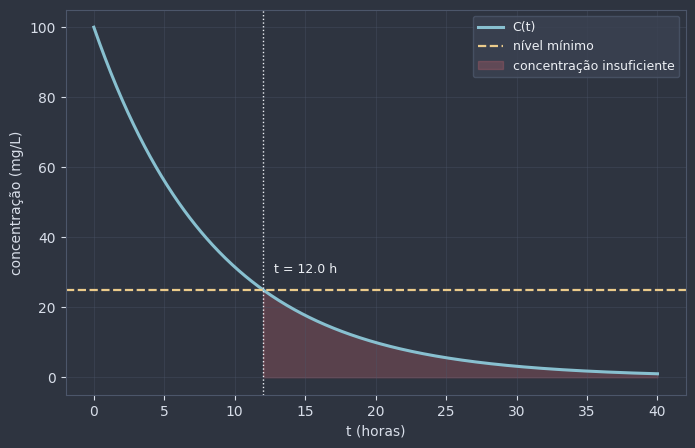


conferindo com o gráfico: t = 12.0 h  (bate com a álgebra)

resposta: o paciente precisa tomar uma nova dose após 12 horas.


In [14]:
# Fechando o gancho: concentração inicial 100 mg/L, meia-vida de 6h,
# nível terapêutico mínimo de 25 mg/L.
C0, meia_vida, nivel_minimo = 100, 6, 25

# 1) Verificação de domínio: t representa tempo, então t >= 0 (não há "tempo negativo" aqui)
print("domínio físico do problema: t >= 0")

# 2) Solução algébrica (técnica do bloco 1)
razao = nivel_minimo / C0
t_max = meia_vida * math.log(razao) / math.log(0.5)
print(f"\nC(t) = {C0}*(0,5)^(t/{meia_vida}) >= {nivel_minimo}")
print(f"(0,5)^(t/{meia_vida}) >= {razao:g}  ->  t <= {meia_vida}*log({razao:g})/log(0,5) = {t_max:.1f} h")
print(f"interseção com o domínio (t>=0):  0 <= t <= {t_max:.1f} horas")

# 3) Conferência gráfica (reaproveitando o widget do bloco 7, agora chamado sem sliders)
t_conferido = visualizar_remedio(C0, meia_vida, nivel_minimo)
print(f"\nconferindo com o gráfico: t = {t_conferido:.1f} h  (bate com a álgebra)")

resposta = f"o paciente precisa tomar uma nova dose após {t_max:.0f} horas"
print(f"\nresposta: {resposta}.")

**Pergunta de checagem:** com tudo que já aprendemos sobre exponencial e logaritmo, o que você imagina que ainda falta para "fechar" esse assunto na prática — sem depender sempre de uma calculadora?

🎯 **Aplicação prática:** é o próprio problema do gancho, finalmente resolvido (veja o código acima).

📖 **Leitura complementar:** [Logaritmo comum](https://pt.wikipedia.org/wiki/Logaritmo_comum)

## Resumo — cheat sheet

| Conceito | Ideia-chave |
|---|---|
| Inequação exponencial geral | aplicar log dos dois lados; se log(a)<0 (0<a<1), o sentido da desigualdade **inverte** |
| Substituição y=aˣ | resolver a inequação polinomial em y; sempre intersectar com y>0 antes de voltar para x |
| Bases diferentes | log dos dois lados + agrupar os termos com x; o sinal do coeficiente resultante decide se inverte |
| Inequação log direta | log_a(f(x)) ◇ c  ⟹  exponenciar dos dois lados, mesma regra de inversão (a>1 mantém, 0<a<1 inverte) |
| Log ◇ log (mesma base) | comparar f(x) e g(x) diretamente; mantém se a>1, inverte se 0<a<1 |
| Solução final de inequação log | **sempre** = solução algébrica ∩ domínio (todo logaritmando > 0) |
| Visualização gráfica | sombrear a região-solução ajuda a confirmar (ou até descobrir) a resposta final |

## Exercícios

**Básico**
1. Resolva uma inequação exponencial geral usando logaritmo, com base entre 0 e 1.
2. Resolva uma inequação logarítmica direta, intersectando com o domínio.

**Intermediário**
3. Resolva uma inequação exponencial por substituição de variável.
4. Resolva uma inequação log ◇ log (mesma base, entre 0 e 1), intersectando com o domínio.

**Desafio**
5. Resolva uma inequação logarítmica cuja solução algébrica precisa ser corrigida pela interseção com o domínio.

Gabarito completo com resolução passo a passo em [`0206b_inequacoes_exponenciais_e_logaritmicas_gabarito.ipynb`](0206b_inequacoes_exponenciais_e_logaritmicas_gabarito.ipynb) — tente resolver sozinho antes de olhar.

### Básico

In [ ]:
# Exercício Básico 1: resolva (0,2)^x < 25 usando logaritmo.
# Guarde a fronteira x_fronteira (float) e, em booleano, se o sentido da
# desigualdade se inverteu (True) ou se manteve (False) ao isolar x.
x_fronteira_exercicio1 = ...
inverteu_exercicio1 = ...  # True ou False

print(x_fronteira_exercicio1, inverteu_exercicio1)

In [ ]:
# Verificação
x_esperado = math.log(25) / math.log(0.2)
assert abs(x_fronteira_exercicio1 - x_esperado) < 1e-6, (
    "Tente de novo, revise: aplique log dos dois lados de (0,2)^x<25 e isole x "
    "(seção 1 - Inequações Exponenciais Gerais)."
)
assert inverteu_exercicio1 is True, (
    "Tente de novo, revise: como a base 0,2 está entre 0 e 1, log(0,2) é negativo "
    "e o sentido da desigualdade se inverte (seção 1 - Inequações Exponenciais Gerais)."
)
print("Certo!")

In [ ]:
# Exercício Básico 2: resolva log_3(x) < 4, intersectando com o domínio.
# Guarde os limites da solução final como uma tupla (limite_inferior, limite_superior).
solucao_exercicio2 = ...  # ex: (a, b)

print(solucao_exercicio2)

In [ ]:
# Verificação
assert solucao_exercicio2 == (0, 81), (
    "Tente de novo, revise: log_3(x)<4  ->  x<3^4=81; intersectando com o domínio (x>0), "
    "a solução final é 0<x<81 (seção 4 - Inequações Logarítmicas Diretas)."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: resolva 9^x - 10*3^x + 9 < 0 por substituição y = 3^x.
# Guarde os limites da solução final em x como uma tupla (limite_inferior, limite_superior).
solucao_exercicio3 = ...  # ex: (a, b)

print(solucao_exercicio3)

In [ ]:
# Verificação
assert solucao_exercicio3 == (0, 2), (
    "Tente de novo, revise: com y=3^x, a inequação vira y^2-10y+9<0, cuja solução é 1<y<9; "
    "voltando com x=log_3(y), a solução final é 0<x<2 (seção 2 - Substituição de Variável)."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 4: resolva log_(0,5)(2x-1) > log_(0,5)(x+3),
# intersectando com o domínio. Guarde os limites da solução final
# como uma tupla (limite_inferior, limite_superior).
solucao_exercicio4 = ...  # ex: (a, b)

print(solucao_exercicio4)

In [ ]:
# Verificação
assert solucao_exercicio4 == (0.5, 4), (
    "Tente de novo, revise: base 0,5 está entre 0 e 1, então a comparação INVERTE: "
    "2x-1 < x+3 -> x<4; domínio: 2x-1>0 (x>0,5) e x+3>0 (x>-3); interseção: 0,5<x<4 "
    "(seção 5 - Inequações Logarítmicas com Logaritmo dos Dois Lados)."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 5: resolva log(x-1) + log(x+1) < log(8),
# corrigindo a solução algébrica pela interseção com o domínio.
# Guarde os limites da solução final como uma tupla (limite_inferior, limite_superior).
solucao_exercicio5 = ...  # ex: (a, b)

print(solucao_exercicio5)

In [ ]:
# Verificação
assert solucao_exercicio5 == (1, 3), (
    "Tente de novo, revise: log((x-1)(x+1))<log(8) -> x^2-1<8 -> -3<x<3 (solução algébrica); "
    "mas o domínio exige x-1>0 e x+1>0, ou seja, x>1; a interseção final é 1<x<3 "
    "(seção 6 - Interseção do Domínio com a Solução)."
)
print("Certo!")

## Glossário do bloco

| Termo | Definição |
|---|---|
| Inversão de sinal | ao dividir (ou multiplicar) uma desigualdade por um número negativo, o sentido dela se inverte |
| log(a) negativo | ocorre quando 0<a<1; é o gatilho da inversão em inequações exponenciais e logarítmicas |
| Substituição de variável | trocar aˣ por y para transformar a inequação exponencial numa inequação polinomial em y |
| Restrição y>0 | toda solução em y deve ser positiva, pois aˣ nunca é zero nem negativo |
| Domínio do logaritmo | conjunto de valores em que o logaritmando é positivo; toda solução final deve respeitá-lo |
| Interseção de soluções | combinar a solução algébrica de uma inequação com as condições de existência dos logaritmos envolvidos |
| Região-solução | conjunto de valores de x (geralmente um intervalo) que satisfaz a inequação |

## Conexões

**Isso depende de:**
- [`0205a_equacoes_exponenciais_e_logaritmicas.ipynb`](0205a_equacoes_exponenciais_e_logaritmicas.ipynb) (técnicas gerais com logaritmo)
- [`0204a_funcao_logaritmica.ipynb`](0204a_funcao_logaritmica.ipynb) (comportamento crescente/decrescente)
- [`0202a_funcao_exponencial.ipynb`](0202a_funcao_exponencial.ipynb) (regra simples de inversão de sinal)

**Isso será usado em:**
- [`0207a_logaritmos_decimais.ipynb`](0207a_logaritmos_decimais.ipynb) (característica, mantissa e tábuas de logaritmos)
- 📌 aplicações em farmacologia, ciências ambientais e economia (faixas seguras/viáveis modeladas por exponenciais e logaritmos)